In [1]:
# -----------------------
# 0) Install dependencies
# -----------------------
!pip -q install torch-geometric
!pip -q install pandas numpy matplotlib scikit-learn tqdm

import math
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
from torch.utils.data import DataLoader

from sklearn.metrics import r2_score, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from typing import List, Dict, Tuple, Optional

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.7 MB/s eta 0:00:00


In [2]:
# -----------------------
# 1) Reproducibility
# -----------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [4]:
# -----------------------
# 2) Data loading
# -----------------------
BASE = "https://www.aflowlib.org/API/aflux/"

SELECT = (
    "$catalog(icsd),"
    "compound(*),"
    "auid(*),"
    "agl_debye(*),"
    "agl_acoustic_debye(*),"
    "ael_debye_temperature(*),"
    "agl_gruneisen(*),"
    "agl_heat_capacity_Cv_300K(*),"
    "agl_thermal_conductivity_300K(*),"
    "agl_thermal_expansion_300K(*),"
    "positions_fractional(*),"
    "geometry(*),"
    "$format(json)"
)

PER_PAGE = 500
MAX_PAGES = 15

TARGET_KEY = "agl_thermal_conductivity_300K"

GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "agl_acoustic_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K(*)",
]

POSITION_KEYS = ["positions_fractional", "positions_frac", "positions"]
LATTICE_KEYS  = ["lattice_vectors", "lattice", "cell"]
SPECIES_KEYS  = ["species", "elements", "atomic_symbols"]

session = requests.Session()
session.headers.update({"User-Agent": "colab-aflux-client/1.0"})

In [5]:

KNN_K = 12
EDGE_EPS = 1e-8 #so 1/d+eps cannot be infinity

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
VAL_RATIO = 0.1
HIDDEN = 128
DEPTH = 3


In [6]:
def fetch_page(page: int):
    url = f"{BASE}?{SELECT},$paging({page},{PER_PAGE})"
    print("Fetching:", url)

    r = session.get(url, timeout=120)
    r.raise_for_status()

    if not r.text.strip():
        raise ValueError(f"Empty response from AFLOW.\nURL: {url}")

    try:
        data = r.json()
    except Exception:
        print("Status code:", r.status_code)
        print("Content-Type:", r.headers.get("Content-Type"))
        print("Response preview:")
        print(r.text[:500])
        raise

    if not isinstance(data, list):
        raise ValueError(
            f"Unexpected AFLOW response type: {type(data)}\nURL: {url}\nPreview: {str(data)[:500]}"
        )

    return data, url

In [7]:
def fetch_all_aflow(
    max_pages: int = MAX_PAGES,
    per_page: int = PER_PAGE,
):
    """
    Fetch all AFLOW entries using paging.
    Returns
    -------
    df : pd.DataFrame
    """
    all_rows = []
    last_url = None

    for page in tqdm(range(1, max_pages + 1), desc="Paging AFLOW"):
        rows, last_url = fetch_page(page)
        if len(rows) == 0:
            break
        all_rows.extend(rows)

    print(f"Fetched {len(all_rows)} entries.")
    print("Last URL:", last_url)
    return pd.DataFrame(all_rows)


In [8]:
df = fetch_all_aflow()


Paging AFLOW:   0%|          | 0/15 [00:00<?, ?it/s]

Fetching: https://www.aflowlib.org/API/aflux/?$catalog(icsd),compound(*),auid(*),agl_debye(*),agl_acoustic_debye(*),ael_debye_temperature(*),agl_gruneisen(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),positions_fractional(*),geometry(*),$format(json),$paging(1,500)


Paging AFLOW:   7%|▋         | 1/15 [00:01<00:16,  1.21s/it]

Fetching: https://www.aflowlib.org/API/aflux/?$catalog(icsd),compound(*),auid(*),agl_debye(*),agl_acoustic_debye(*),ael_debye_temperature(*),agl_gruneisen(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),positions_fractional(*),geometry(*),$format(json),$paging(2,500)


Paging AFLOW:  13%|█▎        | 2/15 [00:02<00:12,  1.03it/s]

...

Fetching: https://www.aflowlib.org/API/aflux/?$catalog(icsd),compound(*),auid(*),agl_debye(*),agl_acoustic_debye(*),ael_debye_temperature(*),agl_gruneisen(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),positions_fractional(*),geometry(*),$format(json),$paging(12,500)


Paging AFLOW:  80%|████████  | 12/15 [00:10<00:02,  1.23it/s]

Fetching: https://www.aflowlib.org/API/aflux/?$catalog(icsd),compound(*),auid(*),agl_debye(*),agl_acoustic_debye(*),ael_debye_temperature(*),agl_gruneisen(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),positions_fractional(*),geometry(*),$format(json),$paging(13,500)


Paging AFLOW:  80%|████████  | 12/15 [00:10<00:02,  1.12it/s]

Fetched 5553 entries.
Last URL: https://www.aflowlib.org/API/aflux/?$catalog(icsd),compound(*),auid(*),agl_debye(*),agl_acoustic_debye(*),ael_debye_temperature(*),agl_gruneisen(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),positions_fractional(*),geometry(*),$format(json),$paging(13,500)


In [9]:
# ============================================================
# 3) Extra imports + config
# ============================================================
import copy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from typing import List, Optional
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool

TARGET_KEY = "agl_thermal_conductivity_300K"
POS_KEY = "positions_fractional"
LAT_KEY = "lattice_vectors"

GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_acoustic_debye",
    "spacegroup_relax",
]

POSITION_KEYS = ["positions_fractional", "positions_cartesian"]
LATTICE_KEYS = ["lattice_vectors", "lattice"]
SPECIES_KEYS = ["species", "species_pp", "species_names"]

TEST_RATIO = 0.1
VAL_RATIO = 0.1
WEIGHT_DECAY = 1e-4
MODEL_SAVE_PATH = "best_model.pt"

In [10]:
# ============================================================
# 4) Periodic table + chemistry helpers
# ============================================================
PERIODIC_TABLE = {
    "H": (1, 1.008), "He": (2, 4.0026),
    "Li": (3, 6.94), "Be": (4, 9.0122), "B": (5, 10.81), "C": (6, 12.011),
    "N": (7, 14.007), "O": (8, 15.999), "F": (9, 18.998), "Ne": (10, 20.180),
    "Na": (11, 22.990), "Mg": (12, 24.305), "Al": (13, 26.982), "Si": (14, 28.085),
    "P": (15, 30.974), "S": (16, 32.06), "Cl": (17, 35.45), "Ar": (18, 39.948),
    "K": (19, 39.098), "Ca": (20, 40.078), "Sc": (21, 44.956), "Ti": (22, 47.867),
    "V": (23, 50.942), "Cr": (24, 51.996), "Mn": (25, 54.938), "Fe": (26, 55.845),
    "Co": (27, 58.933), "Ni": (28, 58.693), "Cu": (29, 63.546), "Zn": (30, 65.38),
    "Ga": (31, 69.723), "Ge": (32, 72.630), "As": (33, 74.922), "Se": (34, 78.971),
    "Br": (35, 79.904), "Kr": (36, 83.798), "Rb": (37, 85.468), "Sr": (38, 87.62),
    "Y": (39, 88.906), "Zr": (40, 91.224), "Nb": (41, 92.906), "Mo": (42, 95.95),
    "Tc": (43, 98.0), "Ru": (44, 101.07), "Rh": (45, 102.91), "Pd": (46, 106.42),
    "Ag": (47, 107.8682), "Cd": (48, 112.414), "In": (49, 114.818), "Sn": (50, 118.71),
    "Sb": (51, 121.76), "Te": (52, 127.60), "I": (53, 126.904), "Xe": (54, 131.293),
    "Cs": (55, 132.905), "Ba": (56, 137.327), "La": (57, 138.905), "Ce": (58, 140.116),
    "Pr": (59, 140.908), "Nd": (60, 144.242), "Pm": (61, 145.0), "Sm": (62, 150.36),
    "Eu": (63, 151.964), "Gd": (64, 157.25), "Tb": (65, 158.925), "Dy": (66, 162.50),
    "Ho": (67, 164.930), "Er": (68, 167.259), "Tm": (69, 168.934), "Yb": (70, 173.045),
    "Lu": (71, 174.967), "Hf": (72, 178.49), "Ta": (73, 180.948), "W": (74, 183.84),
    "Re": (75, 186.207), "Os": (76, 190.23), "Ir": (77, 192.217), "Pt": (78, 195.084),
    "Au": (79, 196.967), "Hg": (80, 200.592), "Tl": (81, 204.38), "Pb": (82, 207.2),
    "Bi": (83, 208.980), "Po": (84, 209.0), "At": (85, 210.0), "Rn": (86, 222.0)
}

def parse_formula(formula: str):
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", str(formula))
    counts = {}
    expanded = []
    for sym, num in tokens:
        n = int(num) if num else 1
        counts[sym] = counts.get(sym, 0) + n
        expanded.extend([sym] * n)
    return expanded, counts

def assign_masses(compound: str):
    elems, _ = parse_formula(compound)
    masses, Zs = [], []
    for sym in elems:
        if sym not in PERIODIC_TABLE:
            raise KeyError(f"Unknown element in formula: {sym}")
        Z, m = PERIODIC_TABLE[sym]
        Zs.append(int(Z))
        masses.append(float(m))
    return masses, Zs

In [11]:
# ============================================================
# 5) Graph building helpers
# ============================================================
def _first_existing_key(entry: dict, keys: List[str]) -> Optional[str]:
    for k in keys:
        if k in entry and entry[k] is not None:
            return k
    return None

def _wrap_frac_delta(df_: np.ndarray):
    return df_ - np.round(df_)

def _coerce_lattice(obj):
    if obj is None:
        return None
    arr = np.array(obj, dtype=float)
    if arr.shape == (3, 3):
        return arr
    if arr.size == 9:
        return arr.reshape(3, 3)
    return None

def pbc_distances(frac: np.ndarray, lattice: Optional[np.ndarray]):
    frac = np.asarray(frac, dtype=float)
    df_ = frac[None, :, :] - frac[:, None, :]
    df_ = _wrap_frac_delta(df_)
    dvec = df_ if lattice is None else (df_ @ np.asarray(lattice, dtype=float))
    return np.linalg.norm(dvec, axis=-1)

def assign_edges(positions_fractional: np.ndarray, lattice: Optional[np.ndarray], k: int = 12):
    frac = np.asarray(positions_fractional, dtype=float)
    N = frac.shape[0]
    D = pbc_distances(frac, lattice)

    srcs, dsts, dists = [], [], []
    for i in range(N):
        idx = np.argsort(D[i])
        idx = idx[idx != i]
        for j in idx[:min(k, len(idx))]:
            srcs.append(i)
            dsts.append(int(j))
            dists.append(float(D[i, j]))

    edge_index = torch.tensor([srcs, dsts], dtype=torch.long)
    dist_arr = np.array(dists, dtype=float)
    return edge_index, dist_arr

def assign_global_attributes(entry: dict, keys: List[str]):
    vals = []
    for k in keys:
        v = entry.get(k, np.nan)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            v = 0.0
        vals.append(float(v))
    return torch.tensor(vals, dtype=torch.float32).view(1, -1)

In [12]:
# ============================================================
# 6) Build graph from AFLOW entry
# ============================================================
def build_graph_from_entry(entry: dict, k: int = 12):
    pos_key = _first_existing_key(entry, POSITION_KEYS)
    if pos_key is None:
        raise KeyError(f"No positions key found. Tried {POSITION_KEYS}")

    frac = np.array(entry[pos_key], dtype=float)
    if frac.ndim != 2 or frac.shape[1] != 3:
        raise ValueError(f"Positions {pos_key} has invalid shape: {frac.shape}")

    lat_key = _first_existing_key(entry, LATTICE_KEYS)
    lattice = _coerce_lattice(entry.get(lat_key)) if lat_key else None

    species_key = _first_existing_key(entry, SPECIES_KEYS)

    if species_key is not None:
        species = list(entry[species_key])
        Zs, masses = [], []
        for s in species:
            if s not in PERIODIC_TABLE:
                raise KeyError(f"Unknown species: {s}")
            Z, m = PERIODIC_TABLE[s]
            Zs.append(float(Z))
            masses.append(float(m))
    else:
        masses, Zs = assign_masses(entry["compound"])

    n_sites = len(frac)
    if len(Zs) != n_sites:
        if len(Zs) < n_sites:
            reps = int(np.ceil(n_sites / len(Zs)))
            Zs = (Zs * reps)[:n_sites]
            masses = (masses * reps)[:n_sites]
        else:
            Zs = Zs[:n_sites]
            masses = masses[:n_sites]

    x = torch.tensor(np.stack([Zs, masses], axis=1), dtype=torch.float32)

    edge_index, dist_arr = assign_edges(frac, lattice, k=k)
    inv_d = 1.0 / (dist_arr + EDGE_EPS)
    edge_attr = torch.tensor(np.stack([dist_arr, inv_d], axis=1), dtype=torch.float32)

    u = assign_global_attributes(entry, GLOBAL_FEATURE_KEYS)

    y_raw = float(entry[TARGET_KEY])
    y = torch.tensor([[np.log1p(y_raw)]], dtype=torch.float32)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        u=u,
        y=y
    )
    data.compound = str(entry.get("compound", "unknown"))
    data.auid = str(entry.get("auid", "unknown"))
    return data


def df_to_graphs(df: pd.DataFrame, k: int = 12, limit: Optional[int] = None):
    graphs, skipped = [], []
    n = len(df) if limit is None else min(len(df), limit)

    for i in tqdm(range(n), desc="Building graphs"):
        entry = df.iloc[i].to_dict()
        try:
            graphs.append(build_graph_from_entry(entry, k=k))
        except Exception as e:
            skipped.append((i, str(e)))

    print(f"Built graphs: {len(graphs)} / {n}, skipped: {len(skipped)}")
    return graphs, skipped

In [13]:
# ============================================================
# Convert dataframe to graphs
# ============================================================

from tqdm import tqdm

def df_to_graphs(df,k=12):

    graphs=[]

    for i in tqdm(range(len(df))):

        entry=df.iloc[i].to_dict()

        try:

            g=build_graph_from_entry(entry,k)

            graphs.append(g)

        except:

            pass

    print("graphs built:",len(graphs))

    return graphs

In [14]:
graphs = df_to_graphs(df)

100%|██████████| 5553/5553 [00:07<00:00, 721.46it/s]

graphs built: 5320


In [15]:
# ============================================================
# Split dataset
# ============================================================

idx=list(range(len(graphs)))

random.shuffle(idx)

n=len(idx)

n_test=int(n*TEST_RATIO)

n_val=int(n*VAL_RATIO)

train=[graphs[i] for i in idx[:n-n_val-n_test]]
val=[graphs[i] for i in idx[n-n_val-n_test:n-n_test]]
test=[graphs[i] for i in idx[n-n_test:]]

print(len(train),len(val),len(test))

4256 532 532


In [16]:
# ============================================================
# GNN model
# ============================================================

class EdgeMP(MessagePassing):

    def __init__(self,x_dim,e_dim,hidden):

        super().__init__(aggr="add")

        self.msg = nn.Sequential(
            nn.Linear(x_dim+e_dim,hidden),
            nn.ReLU(),
            nn.Linear(hidden,hidden),
            nn.ReLU()
        )

        self.upd = nn.Sequential(
            nn.Linear(x_dim+hidden,hidden),
            nn.ReLU(),
            nn.Linear(hidden,hidden),
            nn.ReLU()
        )

        self.res = nn.Linear(x_dim,hidden)


    def forward(self,x,edge_index,edge_attr):

        m=self.propagate(edge_index,x=x,edge_attr=edge_attr)

        out=self.upd(torch.cat([x,m],dim=-1))

        return out+self.res(x)


    def message(self,x_j,edge_attr):

        return self.msg(torch.cat([x_j,edge_attr],dim=-1))


class GraphRegressor(nn.Module):

    def __init__(self,x_dim,e_dim,u_dim,hidden=128,depth=3):

        super().__init__()

        self.layers=nn.ModuleList([
            EdgeMP(x_dim if i==0 else hidden,e_dim,hidden)
            for i in range(depth)
        ])

        self.head=nn.Sequential(

            nn.Linear(hidden+u_dim,hidden),

            nn.ReLU(),

            nn.Linear(hidden,hidden//2),

            nn.ReLU(),

            nn.Linear(hidden//2,1)

        )


    def forward(self,data):

        x=data.x

        edge_index=data.edge_index

        edge_attr=data.edge_attr

        batch=data.batch

        u=data.u

        for l in self.layers:

            x=l(x,edge_index,edge_attr)

        g=global_mean_pool(x,batch)

        return self.head(torch.cat([g,u],dim=-1))

In [17]:
def train_model(train,val,epochs=10,batch_size=32,lr=1e-3):

    train_loader=DataLoader(train,batch_size=batch_size,shuffle=True)
    val_loader=DataLoader(val,batch_size=batch_size)

    g0=train[0]

    model=GraphRegressor(
        g0.x.size(-1),
        g0.edge_attr.size(-1),
        g0.u.size(-1)
    ).to(device)

    opt=torch.optim.Adam(model.parameters(),lr=lr)

    loss_fn=nn.MSELoss()

    history={"train":[],"val":[]}

    best=1e9

    for epoch in range(epochs):

        model.train()

        tot=0

        for batch in train_loader:

            batch=batch.to(device)

            opt.zero_grad()

            pred=model(batch).view(-1)

            y=batch.y.view(-1)

            loss=loss_fn(pred,y)

            loss.backward()

            opt.step()

            tot+=loss.item()

        train_loss=tot/len(train_loader)

        model.eval()

        tot=0

        with torch.no_grad():

            for batch in val_loader:

                batch=batch.to(device)

                pred=model(batch).view(-1)

                y=batch.y.view(-1)

                tot+=loss_fn(pred,y).item()

        val_loss=tot/len(val_loader)

        history["train"].append(train_loss)

        history["val"].append(val_loss)

        print(epoch,train_loss,val_loss)

        if val_loss<best:

            best=val_loss

            torch.save(model.state_dict(),MODEL_SAVE_PATH)

    return model,history

In [18]:
model,history = train_model(train,val)

0 1.5307782940230423 0.06349970378419932
1 0.09530711652977127 0.11089309918529847
2 0.11829862641380694 0.05868804893072914
3 0.0774673263409308 0.08235870148329173
4 0.06562060505655923 0.07105750787784071
5 0.08295379294768761 0.0983317671891521
6 0.09103724461300929 0.08832999099703397
7 0.11498739183845377 0.16564783103325786
8 0.06703165990013377 0.05041267262662158
9 0.12666029172172225 0.11700593329527799


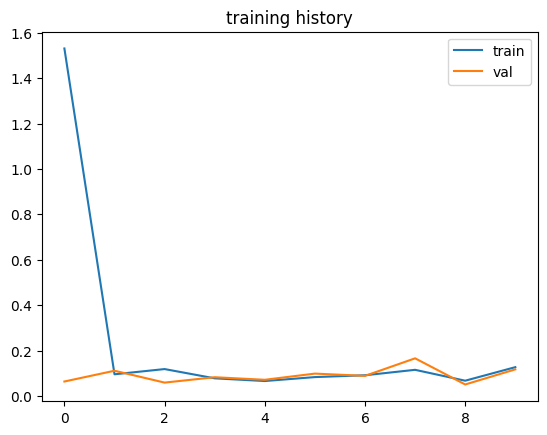

In [19]:
plt.plot(history["train"],label="train")
plt.plot(history["val"],label="val")
plt.legend()
plt.title("training history")
plt.show()

In [20]:
test_loader=DataLoader(test,batch_size=32)

model.load_state_dict(torch.load(MODEL_SAVE_PATH))

model.eval()

true=[]
pred=[]

with torch.no_grad():

    for batch in test_loader:

        batch=batch.to(device)

        p=model(batch).view(-1).cpu().numpy()

        y=batch.y.view(-1).cpu().numpy()

        true.append(y)
        pred.append(p)

true=np.concatenate(true)
pred=np.concatenate(pred)

print("MAE",mean_absolute_error(true,pred))
print("R2",r2_score(true,pred))

MAE 0.1671435385942459
R2 0.92085862159729


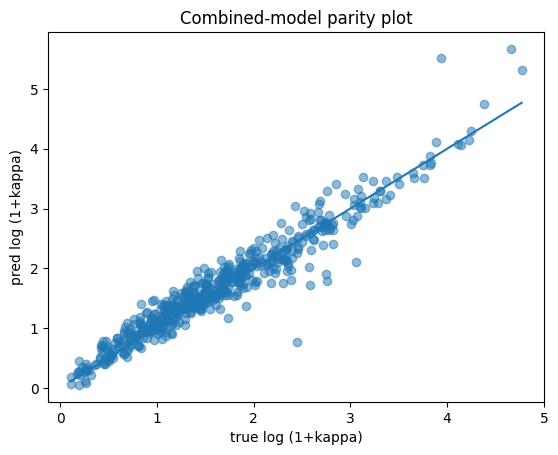

In [35]:
plt.scatter(true,pred,alpha=0.5)

plt.plot([true.min(),true.max()],
         [true.min(),true.max()])

plt.xlabel("true log (1+kappa)")

plt.ylabel("pred log (1+kappa)")

plt.title("Combined-model parity plot")

plt.show()

Text(0.5, 1.0, 'Combined-model parity Plot')

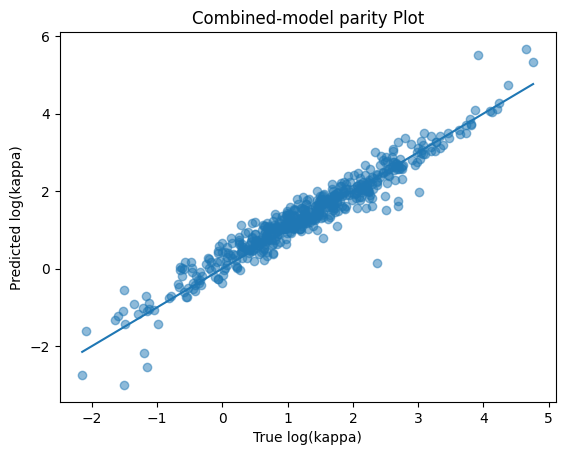

In [36]:


# ---- 从 log(1+kappa) → kappa → log(kappa) ----
true_kappa = np.expm1(true)
pred_kappa = np.expm1(pred)

# 避免 log(0)
eps = 1e-8
true_logk = np.log(true_kappa + eps)
pred_logk = np.log(pred_kappa + eps)

# ---- plot ----
plt.figure()

plt.scatter(true_logk, pred_logk, alpha=0.5)

plt.plot([true_logk.min(), true_logk.max()],
         [true_logk.min(), true_logk.max()])

plt.xlabel("True log(kappa)")
plt.ylabel("Predicted log(kappa)")
plt.title("Combined-model parity Plot")



In [23]:
signed_error = pred_logk - true_logk
abs_error = np.abs(signed_error)

Top outlier compounds (with signed error):

Dy3In3Ir3       | kappa=1.834 | abs_error=2.224 | signed_error=-2.224
Fe1Ga1Ni2       | kappa=3.804 | abs_error=1.591 | signed_error=+1.591
Ce1Te1          | kappa=4.011 | abs_error=1.489 | signed_error=-1.489
Li2Ru2Sn8       | kappa=2.330 | abs_error=1.376 | signed_error=-1.376
C2Sn2Ti4        | kappa=12.421 | abs_error=1.086 | signed_error=-1.086
B6Os4           | kappa=19.441 | abs_error=1.032 | signed_error=-1.032
La1S1           | kappa=9.211 | abs_error=1.015 | signed_error=+1.015
Cd2Ge2Sr1       | kappa=0.615 | abs_error=0.988 | signed_error=-0.988
Ba2Te6          | kappa=1.915 | abs_error=0.985 | signed_error=-0.985
Ag36In16        | kappa=0.205 | abs_error=0.959 | signed_error=+0.959
Ba1O3Sn1        | kappa=7.688 | abs_error=0.932 | signed_error=-0.932
Ho2Pt4          | kappa=4.400 | abs_error=0.849 | signed_error=+0.849
Cs2Cu2O4        | kappa=1.456 | abs_error=0.754 | signed_error=-0.754
Au4Ca4In4       | kappa=0.569 | abs_error=0.

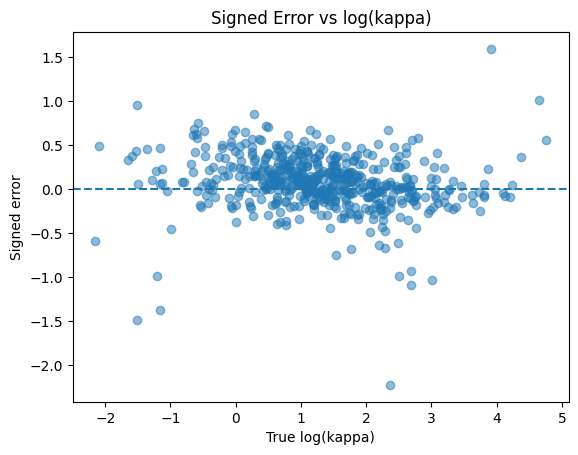

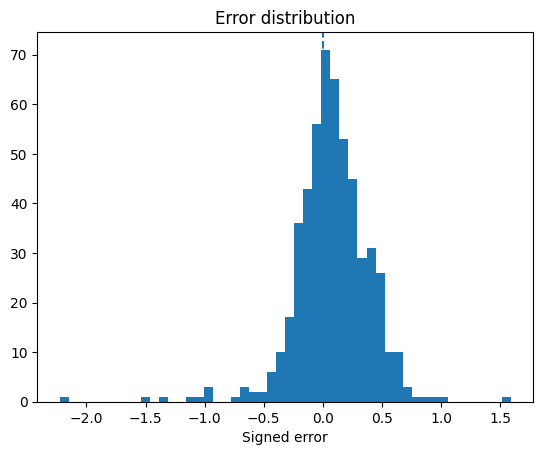

/tmp/ipykernel_2862/2103782353.py:102: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(true_kappa), signed_error, alpha=0.5)


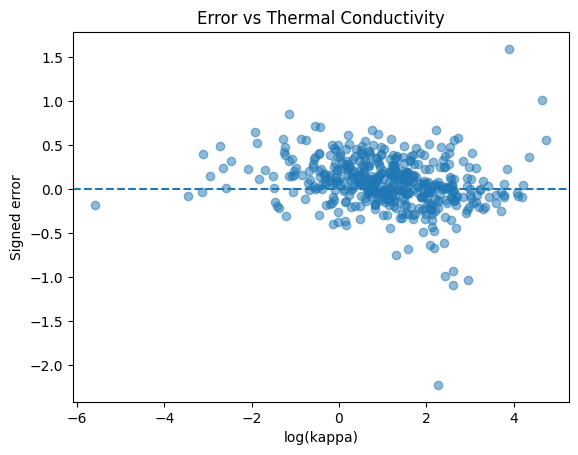

In [25]:

# -----------------------
# 1. 基础误差定义
# -----------------------
signed_error = pred_logk - true_logk
abs_error = np.abs(signed_error)

# -----------------------
# 2. 找 Top 20 Outliers（按绝对误差）
# -----------------------
TOP_N = 20

sorted_idx = np.argsort(abs_error)[::-1]
top_idx = sorted_idx[:TOP_N]

print("Top outlier compounds (with signed error):\n")

for i in top_idx:
    compound = df.iloc[i]["compound"]
    kappa_val = df.iloc[i]["agl_thermal_conductivity_300K"]

    print(
        f"{compound:15s} | "
        f"kappa={kappa_val:.3f} | "
        f"abs_error={abs_error[i]:.3f} | "
        f"signed_error={signed_error[i]:+.3f}"
    )

# -----------------------
# 3. 构造 test_df
# -----------------------
test_df = pd.DataFrame({
    "true_logk": true_logk,
    "pred_logk": pred_logk,
})

test_df["signed_error"] = signed_error
test_df["abs_error"] = abs_error

# -----------------------
# 4. 分类（误差大小）
# -----------------------
bins = [0, 0.5, 1, 2, 5]
labels = ["low", "medium", "high", "extreme"]

test_df["error_category"] = pd.cut(
    test_df["abs_error"],
    bins=bins,
    labels=labels
)

# -----------------------
# 5. 正负分类（bias）
# -----------------------
test_df["error_sign"] = np.where(
    test_df["signed_error"] > 0,
    "over",
    "under"
)

# -----------------------
# 6. 查看分布
# -----------------------
print("\nError category distribution:")
print(test_df["error_category"].value_counts())

print("\nError sign distribution:")
print(test_df["error_sign"].value_counts())

print("\nCross tab (category vs sign):")
print(pd.crosstab(
    test_df["error_category"],
    test_df["error_sign"]
))

# -----------------------
# 7. 可视化
# -----------------------

# (1) Signed error vs log(kappa)
plt.figure()
plt.scatter(true_logk, signed_error, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("True log(kappa)")
plt.ylabel("Signed error")
plt.title("Signed Error vs log(kappa)")
plt.show()


# (2) Error distribution
plt.figure()
plt.hist(signed_error, bins=50)
plt.axvline(0, linestyle="--")
plt.xlabel("Signed error")
plt.title("Error distribution")
plt.show()


# (3) Error vs kappa (physical view)
true_kappa = np.expm1(true_logk)

plt.figure()
plt.scatter(np.log(true_kappa), signed_error, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("log(kappa)")
plt.ylabel("Signed error")
plt.title("Error vs Thermal Conductivity")
plt.show()

In [26]:
test_df["kappa_bin"] = pd.cut(test_df["true_logk"], bins=5)

print("\nMean error per kappa bin:")
print(test_df.groupby("kappa_bin")["abs_error"].mean())
test_df.groupby("kappa_bin")["signed_error"].mean()


Mean error per kappa bin:
kappa_bin
(-2.157, -0.768]    0.442922
(-0.768, 0.614]     0.269049
(0.614, 1.997]      0.198147
(1.997, 3.379]      0.235682
(3.379, 4.761]      0.270036
Name: abs_error, dtype: float32


/tmp/ipykernel_2862/1268535300.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(test_df.groupby("kappa_bin")["abs_error"].mean())
/tmp/ipykernel_2862/1268535300.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_df.groupby("kappa_bin")["signed_error"].mean()


,signed_error
kappa_bin,
"(-2.157, -0.768]",-0.024652
"(-0.768, 0.614]",0.205989
"(0.614, 1.997]",0.096226
"(1.997, 3.379]",-0.071922
"(3.379, 4.761]",0.163557


In [27]:
import re

def count_elements(compound):
    return len(re.findall(r'[A-Z][a-z]?', compound))

test_df["num_elements"] = df.iloc[top_idx]["compound"].apply(count_elements)

print("\nError vs number of elements:")
print(test_df.groupby("num_elements")["abs_error"].mean())


Error vs number of elements:
num_elements
2.0    0.959139
3.0    1.039849
Name: abs_error, dtype: float32


###Feature Ablation


In [28]:
# -----------------------
# Global feature ablation setup
# -----------------------
FULL_GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "agl_acoustic_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

print("Full global features:", FULL_GLOBAL_FEATURE_KEYS)

Full global features: ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']


In [29]:
def run_global_feature_experiment(
    df,
    global_feature_keys,
    seed=42,
    test_ratio=0.1,
    val_ratio=0.1,
    k=12,
    epochs=10,
    batch_size=32,
    lr=1e-3,
):
    # use new global feature list
    global GLOBAL_FEATURE_KEYS
    GLOBAL_FEATURE_KEYS = global_feature_keys

    # rebuild graphs
    graphs = df_to_graphs(df, k=k)
    print(f"Graphs built with features {global_feature_keys}: {len(graphs)}")

    # split
    idx = list(range(len(graphs)))
    random.Random(seed).shuffle(idx)

    n = len(idx)
    n_test = int(n * test_ratio)
    n_val = int(n * val_ratio)

    train = [graphs[i] for i in idx[:n - n_val - n_test]]
    val   = [graphs[i] for i in idx[n - n_val - n_test:n - n_test]]
    test  = [graphs[i] for i in idx[n - n_test:]]

    # train
    model, history = train_model(
        train, val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr
    )

    # evaluate
    test_loader = DataLoader(test, batch_size=batch_size)
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()

    true, pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            p = model(batch).view(-1).cpu().numpy()
            y = batch.y.view(-1).cpu().numpy()
            true.append(y)
            pred.append(p)

    true = np.concatenate(true)
    pred = np.concatenate(pred)

    mae = mean_absolute_error(true, pred)
    r2  = r2_score(true, pred)

    return {
        "features": list(global_feature_keys),
        "n_features": len(global_feature_keys),
        "mae_log": mae,
        "r2_log": r2,
        "history": history,
    }

In [30]:
baseline_result = run_global_feature_experiment(
    df=df,
    global_feature_keys=FULL_GLOBAL_FEATURE_KEYS,
    seed=42,
    test_ratio=TEST_RATIO,
    val_ratio=VAL_RATIO,
    k=KNN_K,
    epochs=10,
    batch_size=32,
    lr=1e-3,
)

print("Baseline full model:")
print("Features:", baseline_result["features"])
print("MAE (log space):", baseline_result["mae_log"])
print("R2  (log space):", baseline_result["r2_log"])

100%|██████████| 5553/5553 [00:03<00:00, 1409.53it/s]


graphs built: 5320
Graphs built with features ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']: 5320
0 0.5194155281563675 0.06267540354062529
1 0.08075121672529924 0.06017885050352882
2 0.07420980325318817 0.05212738868944785
3 0.09298155459582358 0.06347301690017476
4 0.09055120722019583 0.062315305585370344
5 0.07175085386891562 0.05546765577267198
6 0.06526069415915281 0.07505177114816274
7 0.09005505227504816 0.0807391172822784
8 0.07037996080584992 0.08294422902605113
9 0.06585689474429403 0.06702635963173474
Baseline full model:
Features: ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']
MAE (log space): 0.180852472782135
R2  (log space): 0.9184978008270264


In [31]:
ablation_results = []

for feat_to_remove in FULL_GLOBAL_FEATURE_KEYS:
    reduced_features = [f for f in FULL_GLOBAL_FEATURE_KEYS if f != feat_to_remove]

    print("\n" + "="*60)
    print("Removing feature:", feat_to_remove)
    print("Using features:", reduced_features)

    result = run_global_feature_experiment(
        df=df,
        global_feature_keys=reduced_features,
        seed=42,
        test_ratio=TEST_RATIO,
        val_ratio=VAL_RATIO,
        k=KNN_K,
        epochs=10,
        batch_size=32,
        lr=1e-3,
    )

    result["removed_feature"] = feat_to_remove
    result["delta_mae"] = result["mae_log"] - baseline_result["mae_log"]
    result["delta_r2"]  = result["r2_log"] - baseline_result["r2_log"]

    ablation_results.append(result)


Removing feature: agl_debye
Using features: ['agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']


100%|██████████| 5553/5553 [00:03<00:00, 1433.12it/s]


graphs built: 5320
Graphs built with features ['agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']: 5320
0 0.7221212692950901 0.12043073159806869
1 0.09671102410980634 0.08073665157837026
2 0.09302740698134092 0.31443805379026074
3 0.12469665798589699 0.22939185140764012
4 0.10000583358613171 0.06611138209700584
5 0.09935651375050832 0.08383983132593772
6 0.0807933754994905 0.06371081971070346
7 0.07308555610085789 0.06433977690689704
8 0.07323618948851761 0.04829252960489077
9 0.06913538494224387 0.06004638312494054

Removing feature: agl_acoustic_debye
Using features: ['agl_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']


100%|██████████| 5553/5553 [00:05<00:00, 1025.30it/s]


graphs built: 5320
Graphs built with features ['agl_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']: 5320
0 0.89867003637373 0.0737811094697784
1 0.09295334098370452 0.07816368998850093
2 0.07979674077123627 0.0643335350734346
3 0.08017012244440559 0.06396073924706262
4 0.18592755748589235 0.09419144865344553
5 0.07650999568010632 0.05709130864809541
6 0.0751541499748714 0.08290349976981387
7 0.06887532651592466 0.1105633016456576
8 0.08657030231858555 0.13200975494349704
9 0.07575435041540995 0.051685585366452444

Removing feature: ael_debye_temperature
Using features: ['agl_debye', 'agl_acoustic_debye', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']


...

graphs built: 5320
Graphs built with features ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_heat_capacity_Cv_300K', 'agl_thermal_expansion_300K']: 5320
0 2.460943005250809 0.1177947168402812
1 0.107894756572139 0.10314411012565389
2 0.09759292266982839 0.0928178863490329
3 0.09656825381562226 0.10087545939228114
4 0.09413559984107663 0.06656214879716144
5 0.08795526847803503 0.06869213370715871
6 0.07637766883113331 0.06641794916461496
7 0.0818558057868167 0.07803985279272585
8 0.08755011093291573 0.06573657494257479
9 0.08459882663660928 0.0952407531440258

Removing feature: agl_heat_capacity_Cv_300K
Using features: ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_thermal_expansion_300K']


100%|██████████| 5553/5553 [00:03<00:00, 1635.15it/s]


graphs built: 5320
Graphs built with features ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_thermal_expansion_300K']: 5320
0 1.2927844637822836 0.13739242492353215
1 0.12290579937678531 0.17666316996602452
2 0.09459223130479791 0.10407016974161654
3 0.08864377069294005 0.06441360646310974
4 0.09455513116672523 0.1230065511430011
5 0.10209718439027779 0.12653119555291006
6 0.10676636549651175 0.13526444487711964
7 0.1189537990026008 0.05781620872371337
8 0.07408707081935459 0.05196564644575119
9 0.05639839937028132 0.0417365604902015

Removing feature: agl_thermal_expansion_300K
Using features: ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K']


100%|██████████| 5553/5553 [00:03<00:00, 1620.86it/s]


graphs built: 5320
Graphs built with features ['agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K']: 5320
0 0.6740250752160424 0.14604808872236924
1 0.12004269382223151 0.12267811333431917
2 0.10279617136470358 0.08222122906762011
3 0.09869476615038134 0.0757904127240181
4 0.0816151453112077 0.05589667137931375
5 0.09453766743995641 0.07792030910358709
6 0.07495368994716414 0.05176180338158327
7 0.0839771217197404 0.0664348267018795
8 0.07801419740220658 0.052566912792184776
9 0.05851238842745472 0.04866256258066963


In [32]:
ablation_df = pd.DataFrame([
    {
        "removed_feature": r["removed_feature"],
        "mae_log": r["mae_log"],
        "r2_log": r["r2_log"],
        "delta_mae": r["delta_mae"],
        "delta_r2": r["delta_r2"],
    }
    for r in ablation_results
])

# the larger delta_mae is -> feature more important
ablation_df = ablation_df.sort_values("delta_mae", ascending=False)

print("\nFeature ablation summary:")
print(ablation_df)


Feature ablation summary:
              removed_feature   mae_log    r2_log  delta_mae  delta_r2
3               agl_gruneisen  0.201800  0.900304   0.020948 -0.018194
1          agl_acoustic_debye  0.173556  0.925544  -0.007296  0.007046
5  agl_thermal_expansion_300K  0.170302  0.931115  -0.010550  0.012617
0                   agl_debye  0.170171  0.924089  -0.010682  0.005591
4   agl_heat_capacity_Cv_300K  0.152927  0.938460  -0.027926  0.019962
2       ael_debye_temperature  0.146173  0.942812  -0.034679  0.024315


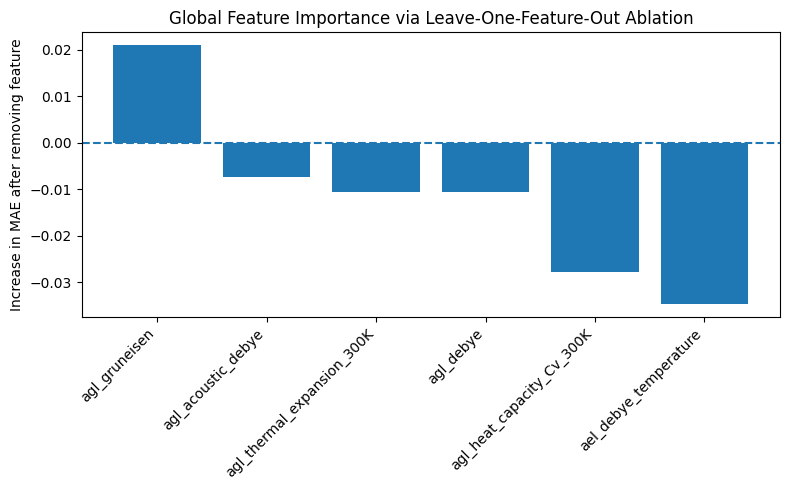

In [33]:
plt.figure(figsize=(8,5))
plt.bar(ablation_df["removed_feature"], ablation_df["delta_mae"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Increase in MAE after removing feature")
plt.title("Global Feature Importance via Leave-One-Feature-Out Ablation")
plt.tight_layout()
plt.show()